# Part 2 — PEFT Methods In A Few-Shot Setting

**Default task:** adapt a pretrained ViT backbone to EuroSAT with 1, 3, 6 labeled examples per class.

**Methods compared by default:**

- linear probe
- LoRA
- full fine-tuning baseline

The goal is to see how method choice changes with data availability & domain gap.


The reusable experiment code lives in `notebooks/part2_peft_workshop.py`, and plotting helpers live in `notebooks/plot_part2_results.py`.

## 0. Colab / Repository Setup

In [8]:
from pathlib import Path
import os
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules or "COLAB_GPU" in os.environ
REPO_URL = "https://github.com/trofimova/haicon_peft_co.git"

if IN_COLAB:
    repo_dir = Path("/content/haicon_peft_co")
    if not repo_dir.exists():
        subprocess.run(["git", "clone", REPO_URL, str(repo_dir)], check=True)
    os.chdir(repo_dir)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks" and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent.resolve()
elif (ROOT / ".." / "src").exists():
    ROOT = (ROOT / "..").resolve()
elif not (ROOT / "src").exists():
    raise RuntimeError(
        f"Could not locate repository root from {Path.cwd()}. "
        "Run this notebook from the cloned repository or update the Colab setup cell."
    )

NOTEBOOK_DIR = ROOT / "notebooks"
for path in [ROOT, NOTEBOOK_DIR]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

required_paths = [
    ROOT / "src",
    NOTEBOOK_DIR / "part2_peft_workshop.py",
    NOTEBOOK_DIR / "plot_part2_results.py",
]
missing = [str(path) for path in required_paths if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Missing workshop helper files:\n- "
        + "\n- ".join(missing)
        + "\n\nIn Colab this usually means the helper .py files were not committed/pushed "
        "to the GitHub repository that the notebook clones."
    )

print("repo root:", ROOT)
print("notebook helpers:", NOTEBOOK_DIR)


repo root: /Users/jeremiastraub/git/haicon_peft_co
notebook helpers: /Users/jeremiastraub/git/haicon_peft_co/notebooks


## 1. Imports

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

from part2_peft_workshop import WorkshopConfig, get_device, run_experiment_grid
from plot_part2_results import (
    latest_run_dir,
    load_run,
    plot_accuracy_grid,
    plot_generalization_summary,
    plot_shifted_accuracy,
    plot_training_curves,
)

print("device:", get_device())


device: mps


## 2. Configuration

In [10]:
DATASET_NAME = "eurosat"  # options: eurosat, cifar10, medmnist
MEDMNIST_NAME = "pathmnist"  # options: pathmnist, dermamnist, octmnist, organmnist

# available methods: linear_probe, lora, full_ft, visual_prompt, bitfit, partial_ft
METHODS_TO_RUN = ["linear_probe", "lora", "full_ft"]
SHOTS_PER_CLASS = [1, 3, 6]
REPEAT_SEEDS = [42]

DEFAULT_EPOCHS = 4
FULL_FT_EPOCHS = 7
SAVE_FIGURES = False

config = WorkshopConfig(
    model_name="WinKawaks/vit-small-patch16-224",
    dataset_name=DATASET_NAME,
    medmnist_name=MEDMNIST_NAME,
    data_root=str(ROOT / "data"),
    output_root=str(ROOT / "outputs" / "part3"),
    methods_to_run=METHODS_TO_RUN,
    shots_per_class=SHOTS_PER_CLASS,
    repeat_seeds=REPEAT_SEEDS,
    default_epochs=DEFAULT_EPOCHS,
    epochs_by_method={"full_ft": FULL_FT_EPOCHS},
    batch_size=16,
    eval_per_class=10,
    domain_shift_strength=0.35,
    target_adaptation_shots=0,
    lora_rank=8,
    num_prompt_tokens=8,
    lr_by_method={
        "linear_probe": 5e-3,
        "lora": 3e-3,
        "visual_prompt": 3e-3,
        "full_ft": 1e-5,
    },
)

config


WorkshopConfig(model_name='WinKawaks/vit-small-patch16-224', image_size=224, dataset_name='eurosat', medmnist_name='pathmnist', data_root='/Users/jeremiastraub/git/haicon_peft_co/data', data_subset_fraction=None, num_workers=0, batch_size=16, seed=42, repeat_seeds=[42], shots_per_class=[1, 3, 6], eval_per_class=10, domain_shift_strength=0.35, target_adaptation_shots=0, methods_to_run=['linear_probe', 'lora', 'full_ft'], lora_rank=8, lora_target=['query', 'value'], num_prompt_tokens=8, partial_n_blocks=1, default_epochs=4, epochs_by_shot={}, epochs_by_method={'full_ft': 7}, lr_by_method={'linear_probe': 0.005, 'lora': 0.003, 'visual_prompt': 0.003, 'full_ft': 1e-05}, weight_decay=0.01, parameter_budget=250000, output_root='/Users/jeremiastraub/git/haicon_peft_co/outputs/part3')

### Example Images

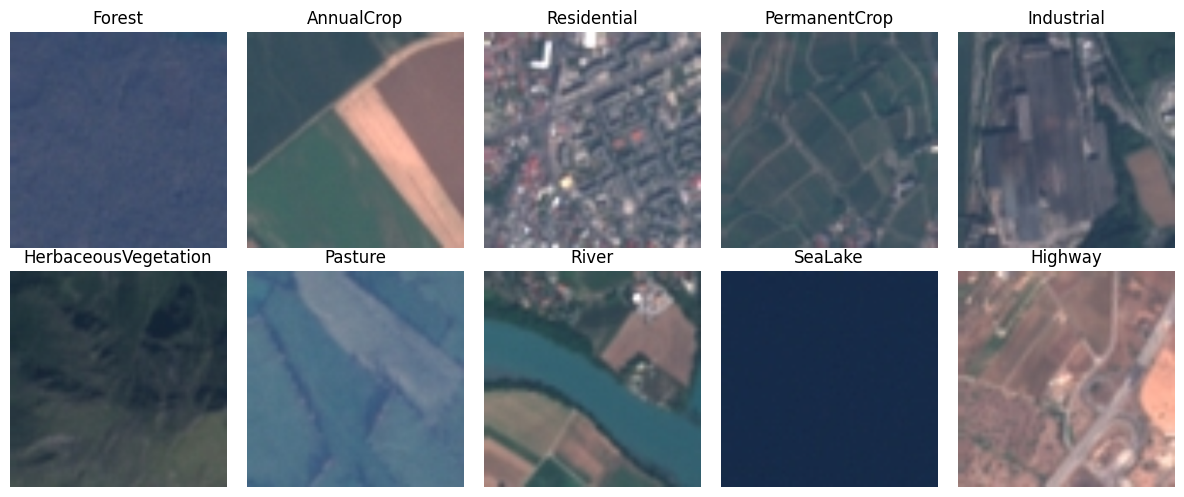

In [11]:
from part2_peft_workshop import get_sample_images

examples = get_sample_images(
    config,
    split="train",
    examples_per_class=1,
    max_classes=10,
)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for ax, (img, label) in zip(axes.ravel(), examples):
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(label, fontsize=12)
    ax.axis("off")

fig.tight_layout()
plt.show()

## 3. Run The Experiment Grid

This cell trains each configured method at each shot count. It writes `results.csv`, `results.json`, `history.csv`, and `config.json` to a timestamped folder under `outputs/part3/`.

In [12]:
run_dir, df, history_df = run_experiment_grid(config)
print("run_dir:", run_dir)

display(
    df[[
        "method", "shots_per_class", "repeat_seed", "epochs",
        "trainable_params", "trainable_pct",
        "train_acc", "source_acc", "target_acc",
        "generalization_gap", "domain_gap",
    ]].sort_values(["shots_per_class", "method"])
)


device: mps
dataset: eurosat
methods: ['linear_probe', 'lora', 'full_ft']
shots/class: [1, 3, 6]
repeat seeds: [42]


Loading weights: 100%|██████████| 198/198 [00:00<00:00, 5410.28it/s]
[transformers] ViTModel LOAD REPORT from: WinKawaks/vit-small-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


feature dim: 384
classes: 10
train examples/class: {0: 2062, 1: 2127, 2: 2097, 3: 1728, 4: 1770, 5: 1392, 6: 1733, 7: 2096, 8: 1743, 9: 2152}
output dir: /Users/jeremiastraub/git/haicon_peft_co/outputs/part3/20260608-121430_eurosat

linear_probe | shots/class=1 | seed=42 | trainable=3,850 | epochs=4


training: 100%|██████████| 4/4 [00:15<00:00,  3.79s/it]



lora | shots/class=1 | seed=42 | trainable=151,306 | epochs=4


...

training: 100%|██████████| 4/4 [00:19<00:00,  4.87s/it]



full_ft | shots/class=6 | seed=42 | trainable=21,817,354 | epochs=7


training: 100%|██████████| 7/7 [00:41<00:00,  5.87s/it]


run_dir: /Users/jeremiastraub/git/haicon_peft_co/outputs/part3/20260608-121430_eurosat


,method,shots_per_class,repeat_seed,epochs,trainable_params,trainable_pct,train_acc,source_acc,target_acc,generalization_gap,domain_gap
2,full_ft,1,42,7,21817354,100.000000,1.000000,0.21,0.15,0.790000,0.06
0,linear_probe,1,42,4,3850,0.017647,1.000000,0.42,0.36,0.580000,0.06
1,lora,1,42,4,151306,0.688856,1.000000,0.44,0.28,0.560000,0.16
5,full_ft,3,42,7,21817354,100.000000,0.966667,0.40,0.22,0.566667,0.18
3,linear_probe,3,42,4,3850,0.017647,1.000000,0.53,0.41,0.470000,0.12
4,lora,3,42,4,151306,0.688856,1.000000,0.61,0.43,0.390000,0.18
8,full_ft,6,42,7,21817354,100.000000,0.966667,0.57,0.33,0.396667,0.24
6,linear_probe,6,42,4,3850,0.017647,1.000000,0.77,0.54,0.230000,0.23
7,lora,6,42,4,151306,0.688856,1.000000,0.75,0.66,0.250000,0.09


## 4. In-Domain And Shifted-Domain Accuracy

The first plot evaluates on the usual validation images. The second plot uses the same validation examples after the controlled target-domain distortion.


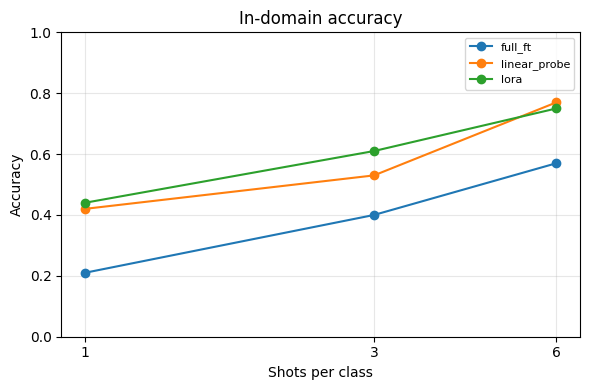

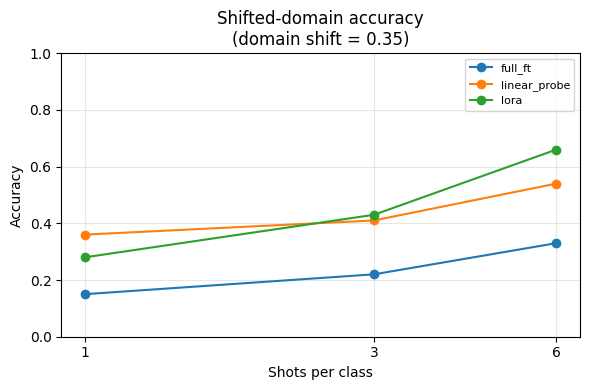

In [13]:
df_plot, history_plot, config_plot = load_run(run_dir)

fig = plot_accuracy_grid(df_plot, config_plot)
if SAVE_FIGURES:
    fig.savefig(run_dir / "accuracy_grid.png", dpi=160)
plt.show()

fig = plot_shifted_accuracy(df_plot, config_plot)
if SAVE_FIGURES:
    fig.savefig(run_dir / "shifted_accuracy.png", dpi=160)
plt.show()


## 5. Additional Diagnostics


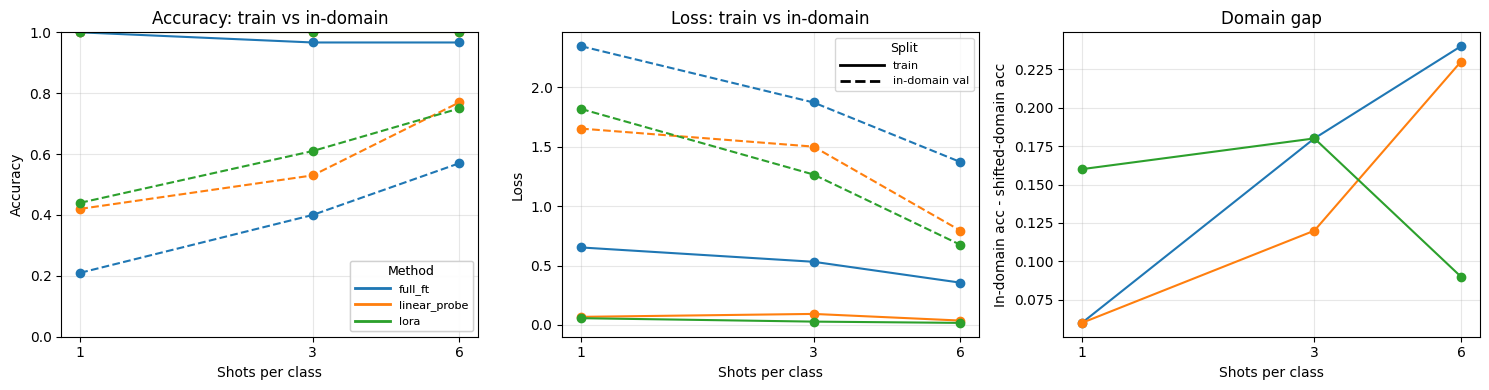

In [14]:
fig = plot_generalization_summary(df_plot)
if SAVE_FIGURES:
    fig.savefig(run_dir / "generalization_summary.png", dpi=160)
plt.show()


## 6. Training Curves

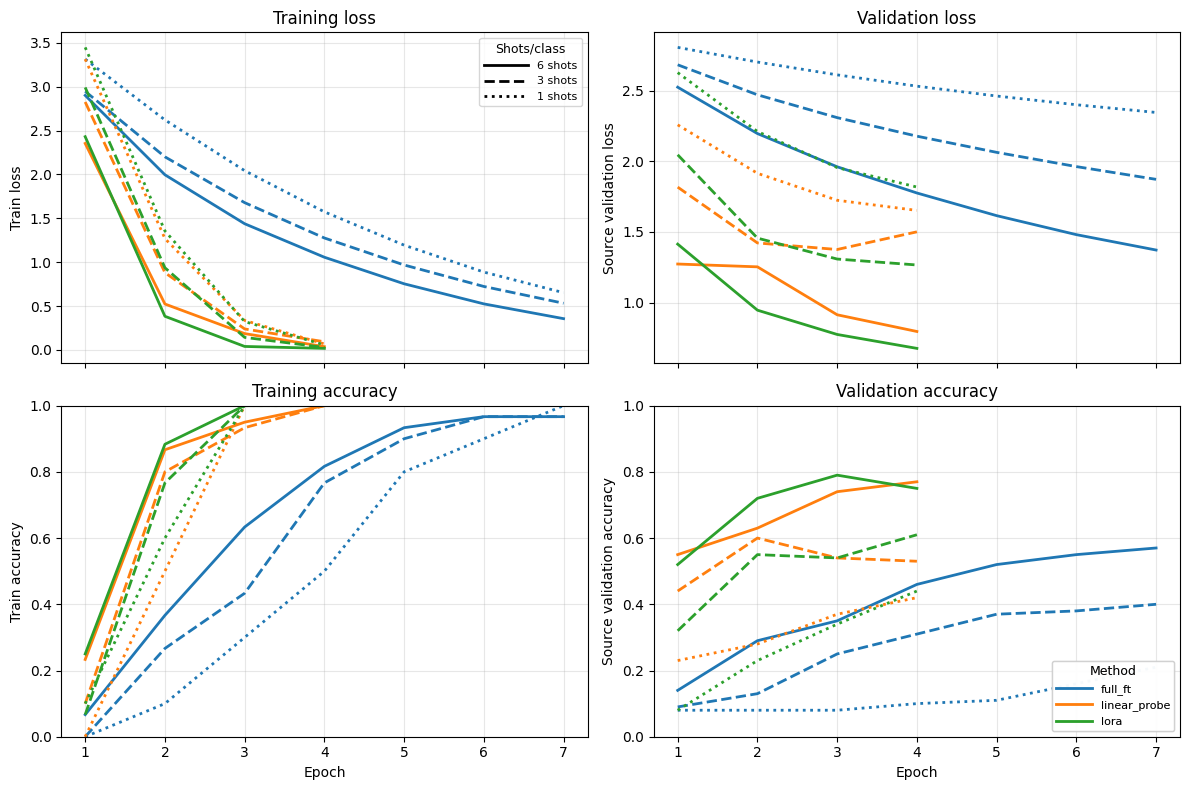

In [15]:
fig = plot_training_curves(history_plot)
if SAVE_FIGURES:
    fig.savefig(run_dir / "training_curves.png", dpi=160)
plt.show()


## 7. Trainable Parameter Counts

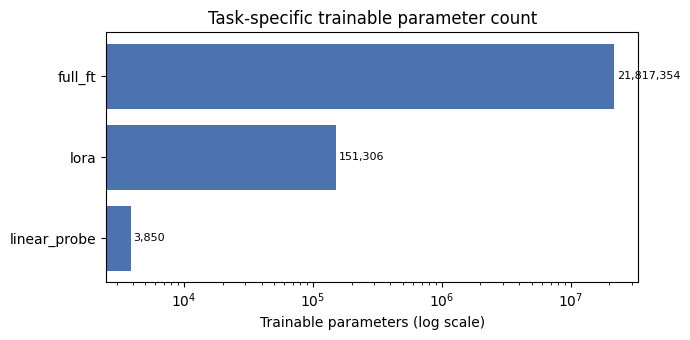

In [16]:
param_df = (
    df_plot.groupby("method", as_index=False)["trainable_params"]
    .first()
    .sort_values("trainable_params")
)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(param_df["method"], param_df["trainable_params"], color="#4c72b0")
ax.set_xscale("log")
ax.set_xlabel("Trainable parameters (log scale)")
ax.set_title("Task-specific trainable parameter count")
for patch, value in zip(ax.patches, param_df["trainable_params"]):
    ax.text(value * 1.05, patch.get_y() + patch.get_height() / 2, f"{value:,}", va="center", fontsize=8)
fig.tight_layout()
if SAVE_FIGURES:
    fig.savefig(run_dir / "trainable_params.png", dpi=160)
plt.show()


## 8. Replot A Saved Run

Use this after restarting the notebook, or to inspect an older run. Leave `RUN_DIR = None` to use the newest output folder.

In [ ]:
RUN_DIR = None

selected_run_dir = Path(RUN_DIR).resolve() if RUN_DIR is not None else latest_run_dir(ROOT / "outputs" / "part3")
df_plot, history_plot, config_plot = load_run(selected_run_dir)
print("selected run:", selected_run_dir)
display(df_plot.head())

for filename, make_fig in [
    ("accuracy_grid.png", lambda: plot_accuracy_grid(df_plot, config_plot)),
    ("shifted_accuracy.png", lambda: plot_shifted_accuracy(df_plot, config_plot)),
    ("training_curves.png", lambda: plot_training_curves(history_plot)),
    ("generalization_summary.png", lambda: plot_generalization_summary(df_plot)),
]:
    fig = make_fig()
    if SAVE_FIGURES:
        fig.savefig(selected_run_dir / filename, dpi=160)
    plt.show()


## Optional Extensions

- Explore other datasets.
- Add repeated seeds.
- Explore the other available PEFT methods.
- Explore other pretrained models.
- Increase `domain_shift_strength` to make the target split harder.
- Add `target_adaptation_shots` to see whether a tiny amount of shifted target data helps.
